In [63]:
# Importing the Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [64]:
# Loading 6he Dataset
data = pd.read_csv('loan_prediction.csv')

In [65]:
# Analyse the Top 5 rows of the Dataset
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [66]:
# Let's drop the loan id column and move further
data.drop(columns = 'Loan_ID', inplace = True)

In [67]:
# Now let’s have a look if the data has missing values
data.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

##### The data has missing values in some of the categorical columns and some numerical columns.

In [68]:
# Now let's take a look at the descriptive statistics of the dataset before filling in the missing values
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


##### Now let’s fill in the missing values. In categorical columns, we can fill in missing values with the mode of each column. The mode represents the value that appears most often in the column and is an appropriate choice when dealing with categorical data

In [69]:
# Fill missing values in categorical columns with mode
data['Gender'].fillna(data['Gender'].mode()[0], inplace = True)
data['Married'].fillna(data['Married'].mode()[0], inplace = True)
data['Dependents'].fillna(data['Dependents'].mode()[0], inplace = True)
data['Self_Employed'].fillna(data['Self_Employed'].mode()[0], inplace = True)

C:\Users\Kamran\AppData\Local\Temp\ipykernel_42416\3196353045.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\Kamran\AppData\Local\Temp\ipykernel_42416\3196353045.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

##### To fill in the missing values of numerical columns, we have to choose appropriate measures:

1. We can fill in the missing values of the loan amount column with the median value. The median is an appropriate measure to fill in missing values when dealing with skewed distributions or when outliers are present in the data;
2. We can fill in the missing values of the loan amount term column with the mode value of the column. Since the term of the loan amount is a discrete value, the mode is an appropriate metric to use;
3. We can fill in the missing values of the credit history column with the mode value. Since credit history is a binary variable (0 or 1), the mode represents the most common value and is an appropriate choice for filling in missing values.

In [70]:
# Fill missing values in Loan Amount with the median
data['LoanAmount'].fillna(data['LoanAmount'].median(), inplace = True)

# Fill missing values in Loan AMount Term with the mode
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0], inplace = True)

# Fill missing values in credit history with the mode
data['Credit_History'].fillna(data['Credit_History'].mode()[0], inplace = True)

C:\Users\Kamran\AppData\Local\Temp\ipykernel_42416\2324401566.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\Kamran\AppData\Local\Temp\ipykernel_42416\2324401566.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

#### Exploratory Data Analysis


In [71]:
import plotly.express as px

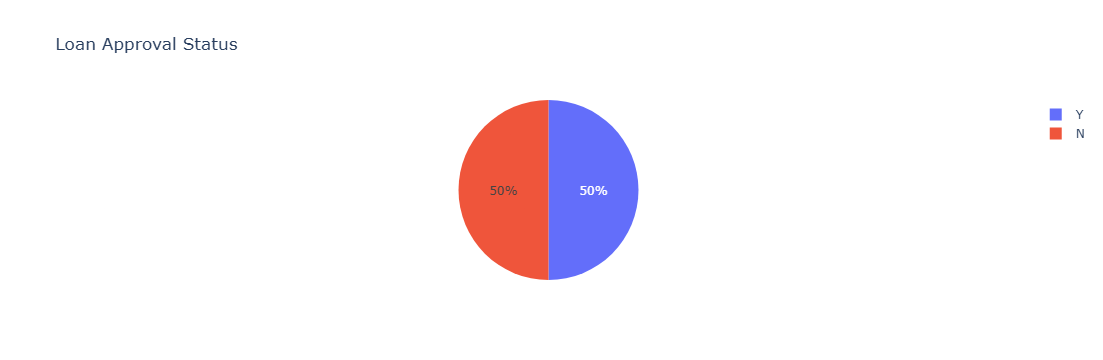

In [72]:
loan_status_count = data['Loan_Status'].value_counts()
fig_loan_status = px.pie(loan_status_count, names = loan_status_count.index, title = 'Loan Approval Status')

fig_loan_status.show()

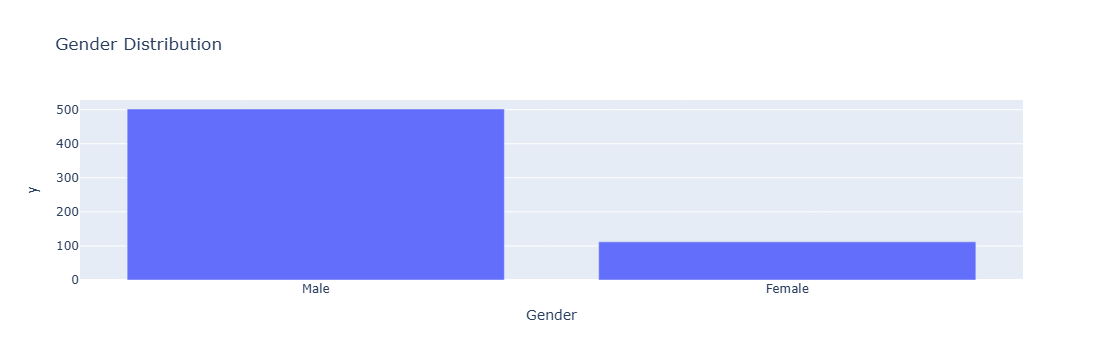

In [73]:
# Now let's have a look at the distribution of the gender column
gender_count = data['Gender'].value_counts()

fig_gender = px.bar(gender_count, x = gender_count.index, y = gender_count.values, title = 'Gender Distribution')

fig_gender.show()

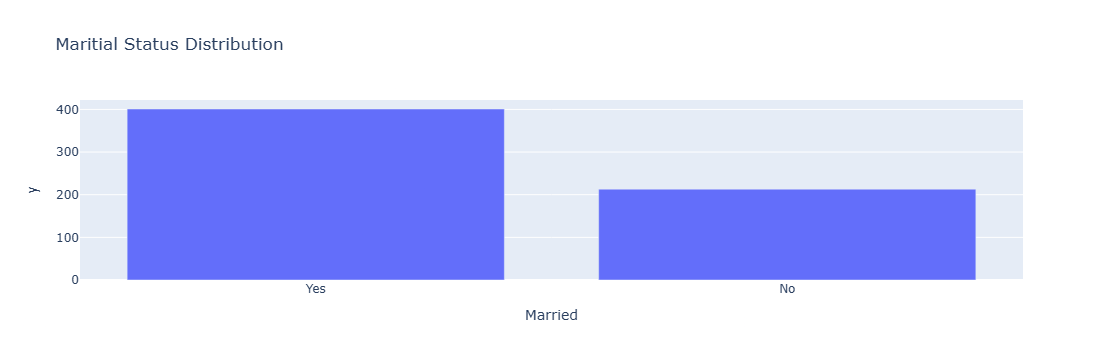

In [74]:
# Now let's have a look at the distribution of the martial status column

married_count = data['Married'].value_counts()

fig_married = px.bar(married_count, x = married_count.index, y = married_count.values, title = 'Maritial Status Distribution')
fig_married.show()

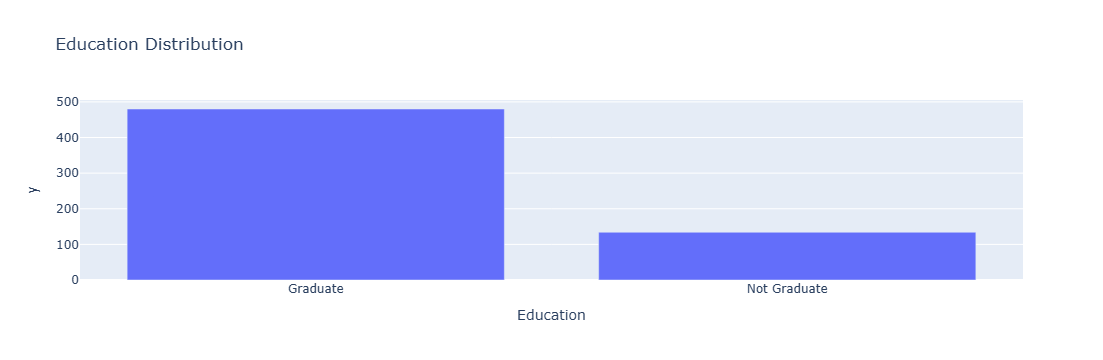

In [75]:
# Now let's have a look at the distribution of the education column
education_count = data['Education'].value_counts()

fig_education = px.bar(education_count, x = education_count.index, y = education_count.values, title = 'Education Distribution')
fig_education.show()

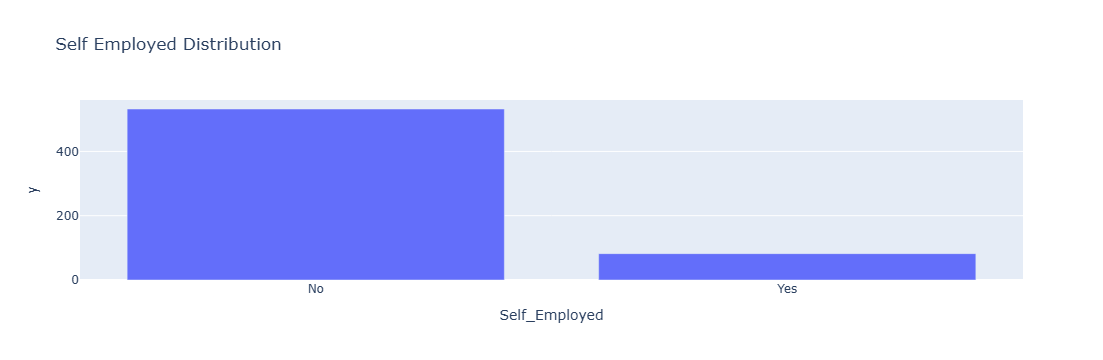

In [76]:
# Now let's have a look at the distribution of the self-employment column
self_employed_count = data['Self_Employed'].value_counts()

fig_self_employed = px.bar(self_employed_count, x = self_employed_count.index, y = self_employed_count.values, title = 'Self Employed Distribution')
fig_self_employed.show()

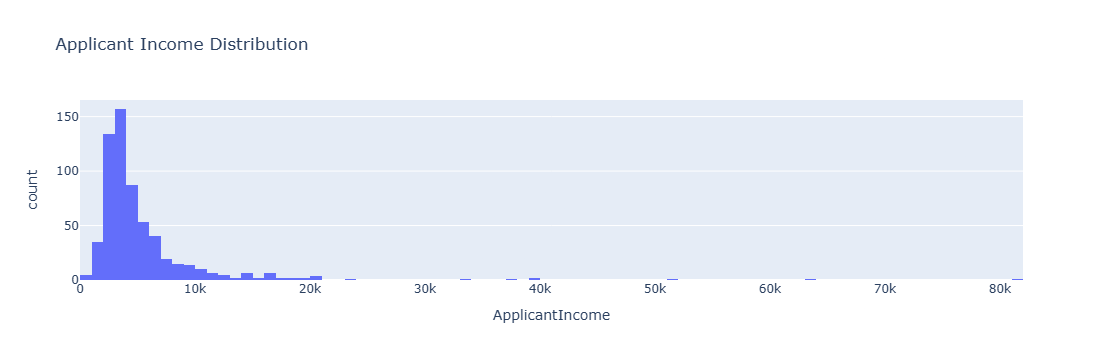

In [77]:
# Now let's have a look at the distribution of the applicant income column
fig_applicant_income = px.histogram(data, x = 'ApplicantIncome', title = 'Applicant Income Distribution')
fig_applicant_income.show()

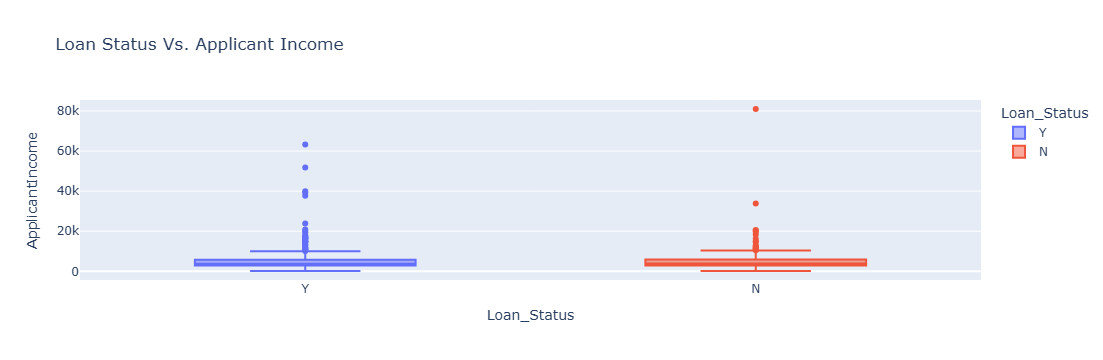

In [78]:
# Now let's have a look at the relationship between the income of the loan applicant and the loan status
fig_income = px.box(data, x = 'Loan_Status', y = 'ApplicantIncome', color = 'Loan_Status', title = 'Loan Status Vs. Applicant Income')
fig_income.show()

##### The “ApplicantIncome” column contains outliers which need to be removed before moving further.

In [79]:
# Calculate the IQR
Q1 = data['ApplicantIncome'].quantile(0.25)
Q3 = data['ApplicantIncome'].quantile(0.75)
IQR = Q3 - Q1

In [80]:
# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [81]:
# Remove outliers
data = data[(data['ApplicantIncome'] >= lower_bound) & (data['ApplicantIncome'] <= upper_bound)]

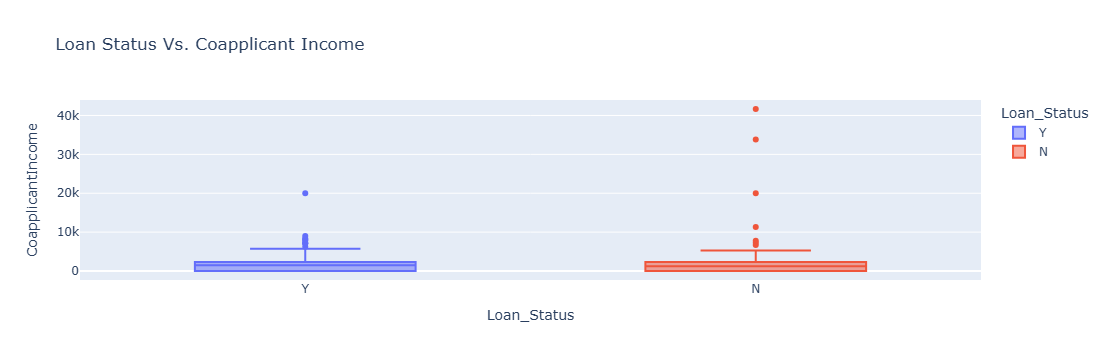

In [82]:
# Now let's have a look at the relationship between the income of the loan co-applicant and the loan status
fig_coapplicant_income = px.box(data, x = 'Loan_Status', y = 'CoapplicantIncome', color = 'Loan_Status', title = 'Loan Status Vs. Coapplicant Income')

fig_coapplicant_income.show()

##### The income of the loan co-applicant also contains outliers. Let’s remove the outliers from this column as well

In [83]:
# Calculate the IQR
Q1 = data['CoapplicantIncome'].quantile(0.25)
Q3 = data['CoapplicantIncome'].quantile(0.75)
IQR = Q3 - Q1

In [84]:
# Define the upper and the lower bound for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [85]:
# Remove outliers
data = data[(data['CoapplicantIncome'] >= lower_bound) & (data['CoapplicantIncome'] <= upper_bound)]

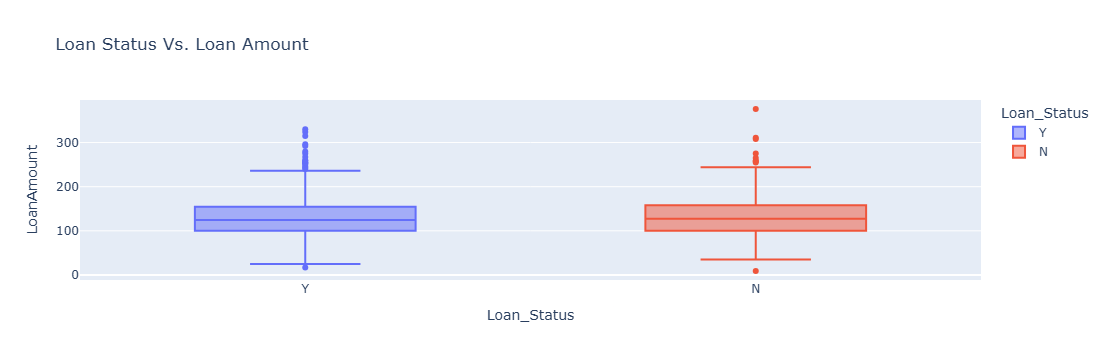

In [86]:
# Now let's have a look at the relationship between the loan amount and the loan status
fig_loan_amount = px.box(data, x = 'Loan_Status', y = 'LoanAmount', color = 'Loan_Status', title ='Loan Status Vs. Loan Amount')

fig_loan_amount.show()

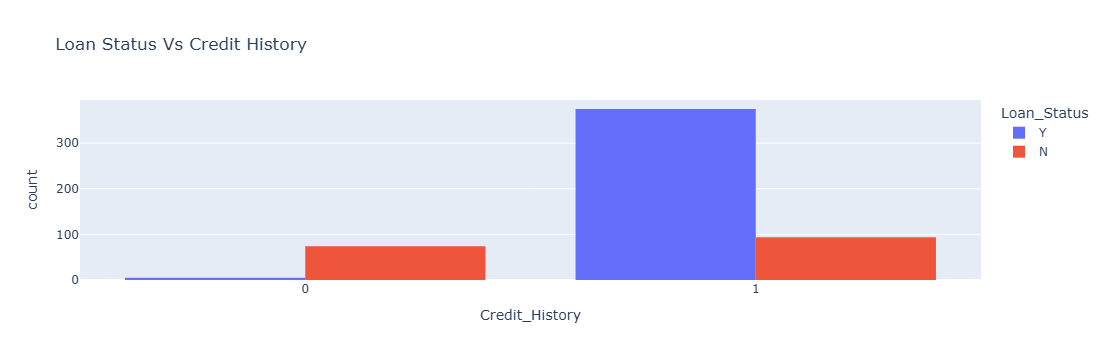

In [87]:
# Now let's have a look at the relationship between credit history and loan status
fig_credit_history = px.histogram(data, x = 'Credit_History', color = 'Loan_Status', barmode = 'group', title ='Loan Status Vs Credit History' )

fig_credit_history.show()

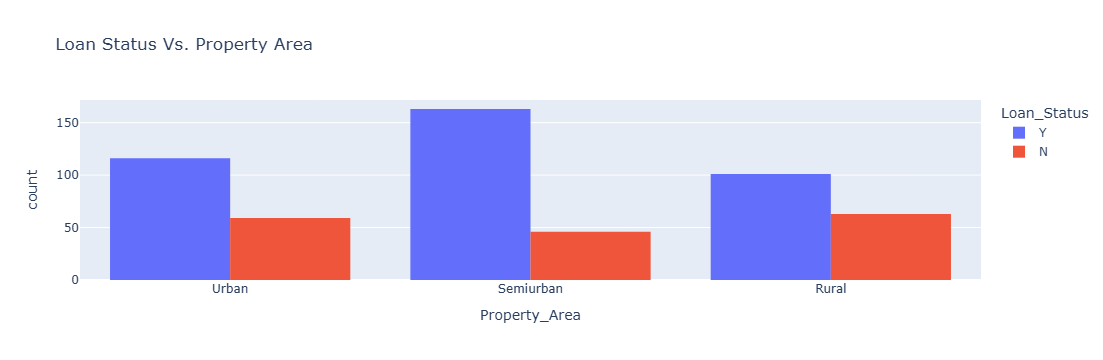

In [88]:
# Now let's have a look at the relationship between the property area and the loan status
fig_property_area = px.histogram(data, x = 'Property_Area', color = 'Loan_Status', barmode = 'group',title = 'Loan Status Vs. Property Area' )

fig_property_area.show()

#### Data Preparation and Training Loan Approval Prediction Model


In [89]:
# Convert categorical columns to numerical ones using one hot encoding
cat_cols = ['Gender', 'Married','Dependents','Education','Self_Employed','Property_Area']
data = pd.get_dummies(data, columns= cat_cols)

In [90]:
# Split the dataset into X and y Features
X = data.drop(columns= 'Loan_Status')
y = data['Loan_Status']

In [91]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [92]:
# Scale the numerical columns using Standard Scaler
# Create a copy to avoid 'SettingWithCopyWarning'
X_train = X_train.copy()
X_test = X_test.copy()

# Ensure numerical columns are float or int
X_train[numerical_cols] = X_train[numerical_cols].astype(float)
X_test[numerical_cols] = X_test[numerical_cols].astype(float)

# Scale the numerical columns
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [93]:
from sklearn.svm import SVC

In [94]:
model = SVC(random_state=42)

In [95]:
model.fit(X_train, y_train)

SVC(random_state=42)

In [96]:
# Now let’s make predictions on the test set
y_pred = model.predict(X_test)
print(y_pred)

['Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y'
 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y'
 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y'
 'Y' 'Y']


##### Now let’s add the predicted loan approval values to the testing set as a new column in a DataFrame called X_test_df and show the predicted loan approval values alongside the original features

In [97]:
# Convert X_test to a DataFrame
X_test_data = pd.DataFrame(X_test, columns=X_test.columns)

# Add the predicted values to X_test_df
X_test_data['Loan_Status_Predicted'] = y_pred
print(X_test_data.head())

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
277        -0.544528          -0.037922   -0.983772          0.305159   
84         -0.067325          -0.931554   -1.571353         -1.430680   
275        -0.734870           0.334654   -0.298262          0.305159   
392        -0.824919           0.522317   -0.200332          0.305159   
537        -0.267373          -0.931554   -0.454950          0.305159   

     Credit_History  Gender_Female  Gender_Male  Married_No  Married_Yes  \
277        0.402248          False         True       False         True   
84         0.402248          False         True       False         True   
275        0.402248          False         True       False         True   
392        0.402248          False         True       False         True   
537        0.402248          False         True        True        False   

     Dependents_0  ...  Dependents_2  Dependents_3+  Education_Graduate  \
277          True  ...       

#### Summary
Loan approval prediction involves the analysis of various factors, such as the applicant’s financial history, income, credit rating, employment status, and other relevant attributes. By leveraging historical loan data and applying machine learning algorithms, businesses can build models to determine loan approvals for new applicants.